# To what the oscillations on time_to_swot diag. are they related to ?

In [41]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from cstes import U

______
# Default parameters

In [124]:
N_traj = 20 #drifters
len_traj = 80 #days
dt_traj = 10/60/24 #10min in days

# For sinusoide velocities
amp = 0.5 #m/s
T = 2.345 #days
lat = 39
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)

#SWOT
dtCycle = 1 #days, time between each cycle
dt = 10 #days, max dt between traj-satellite 
nb_cycle = 40#days

In [148]:
def build_necklace(traj, dt, tCycle):
    tneg =  np.sort(np.arange(0, -dt-dt_traj, -dt_traj))
    tpos = np.sort(np.arange(dt_traj, dt, dt_traj))
    ts = np.concatenate([tneg, tpos])
    dd = traj.interp(traj_time= ts+tCycle)
    dd['traj_time'] = ts
    return dd

    
def compute_for_all(N_traj = N_traj, len_traj = len_traj,dt_traj =dt_traj, amp=amp, T=T, lat=lat, f=f, dtCycle=dtCycle, dt=dt, nb_cycle=nb_cycle ):
    # Initialize
    Tcycle = np.arange(0, nb_cycle, dtCycle)
    traj_time = np.arange(0, len_traj, dt_traj)
    drifter_id = np.arange(N_traj)
    dsggd = xr.DataArray(np.meshgrid(traj_time, drifter_id)[0], coords = {'drifter_id':drifter_id, 'traj_time':traj_time})
    np.random.seed(0)
    phi = xr.DataArray(np.random.rand(N_traj), coords = {'drifter_id':drifter_id})*2*np.pi
    dsggd = f*amp * np.sin(2*np.pi*dsggd/T + phi)/U
    
    #Necklace
    DD = []
    for d in range(N_traj) :
        traj = dsggd.sel(drifter_id=d).dropna('traj_time')
        D = []
        for tc in Tcycle :
            D.append(build_necklace(traj,dt, tc))
        DD.append(xr.concat(D, pd.Index(Tcycle, name = 'tcycle')))
    simple = xr.concat(DD, dim = 'drifter_id').rename(traj_time='timetoswot')
    pos = simple.where(simple.timetoswot >= 0, drop=True)
    neg = simple.where(simple.timetoswot <= 0, drop=True)
    neg['timetoswot'] = - neg['timetoswot']
    neg['tcycle'] = neg['tcycle']+ 0.5
    bended = xr.concat([pos, neg], dim = 'tcycle').sortby('tcycle')
    
    return dsggd, bended, simple

def plot_for_one_traj(simple, bended, i) :
    dsp = simple.isel(drifter_id=i)
    concat = bended.isel(drifter_id=i)
    
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    dsp.plot(ax = axs[0, 0])
    dsp.mean('tcycle').plot(ax = axs[1, 0])
    
    concat.plot(ax = axs[0, 1])
    concat.mean('tcycle').plot(ax = axs[1, 1])
    
    concat.sel(timetoswot = slice(0,1)).plot(ax = axs[0, 2])
    concat.sel(timetoswot = slice(0,1)).mean('tcycle').plot(ax = axs[1, 2])
    for i in range(0, dt) :
        axs[1, 0].axvline(i, ls=':')
        axs[1, 1].axvline(i, ls=':')
    
    for ax in axs[1,:]:
        ax.grid()

def plot_for_all(simple, bended) :
    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    ax=axs[0]
    bended.mean('tcycle').mean('drifter_id').plot(ax=ax)
    for i in range(0, 10) :
        ax.axvline(i, ls=':')
    ax.grid()

    bended.count(dim='tcycle').mean('drifter_id').plot(ax=axs[1])
    

### T=2.345

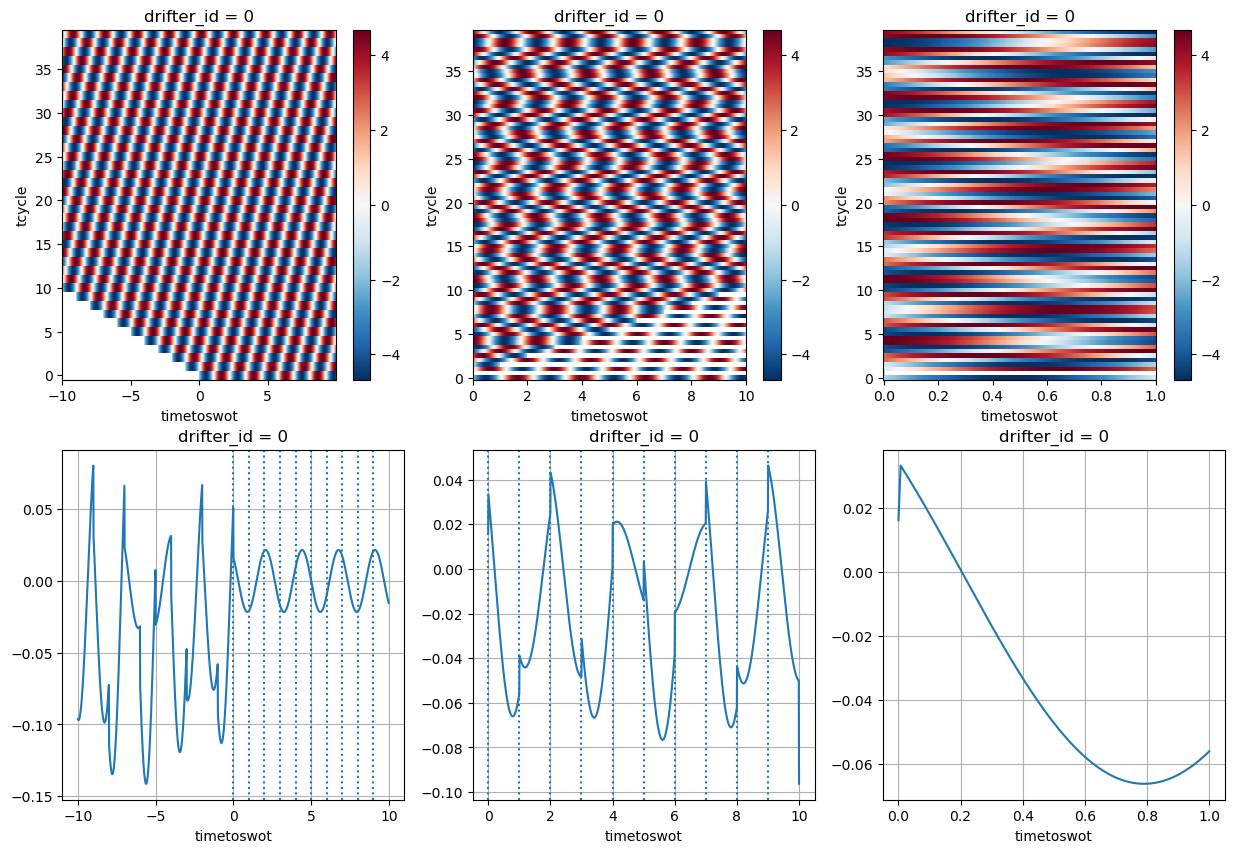

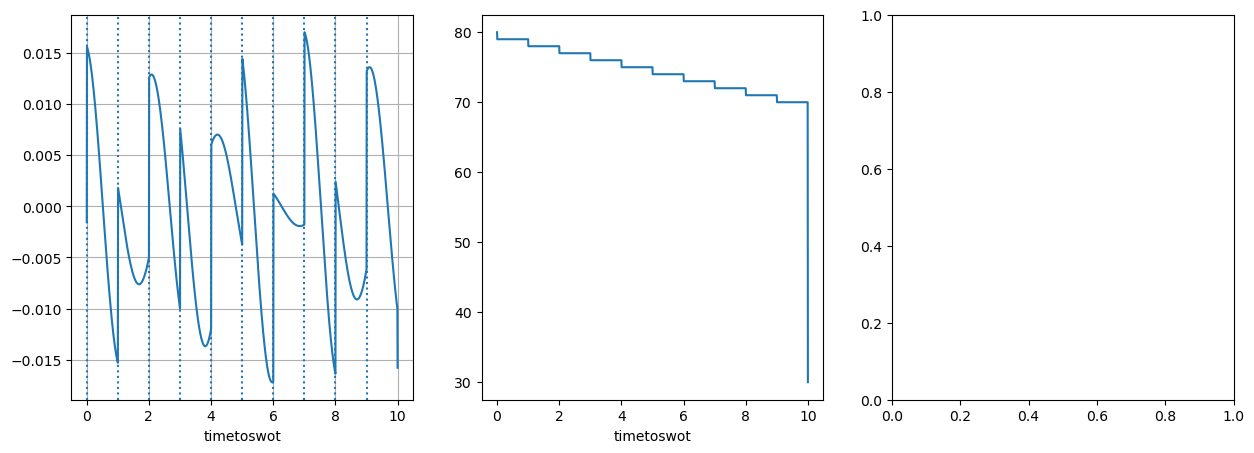

In [149]:
dsggd, bended, simple = compute_for_all()
plot_for_one_traj(simple, bended, 0)
plot_for_all(simple, bended)

###  Removing border affects

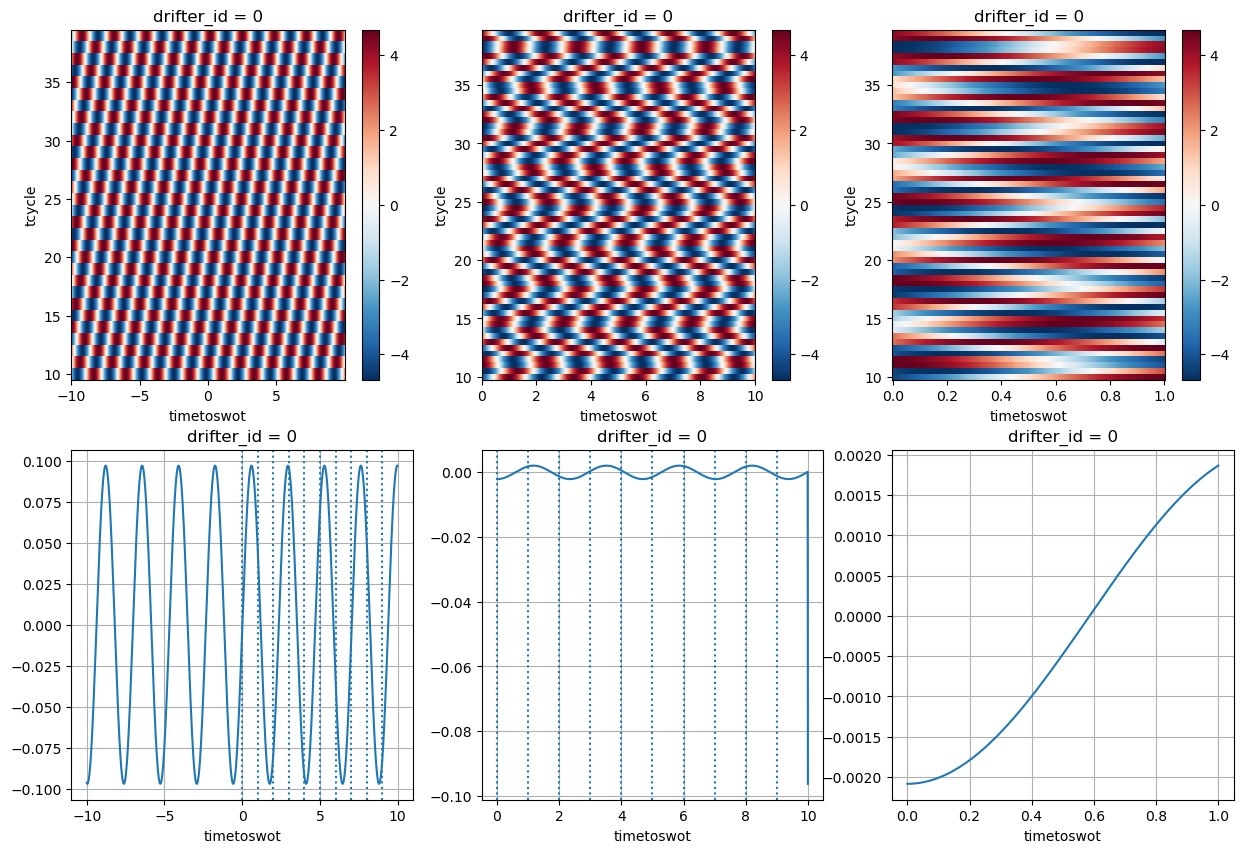

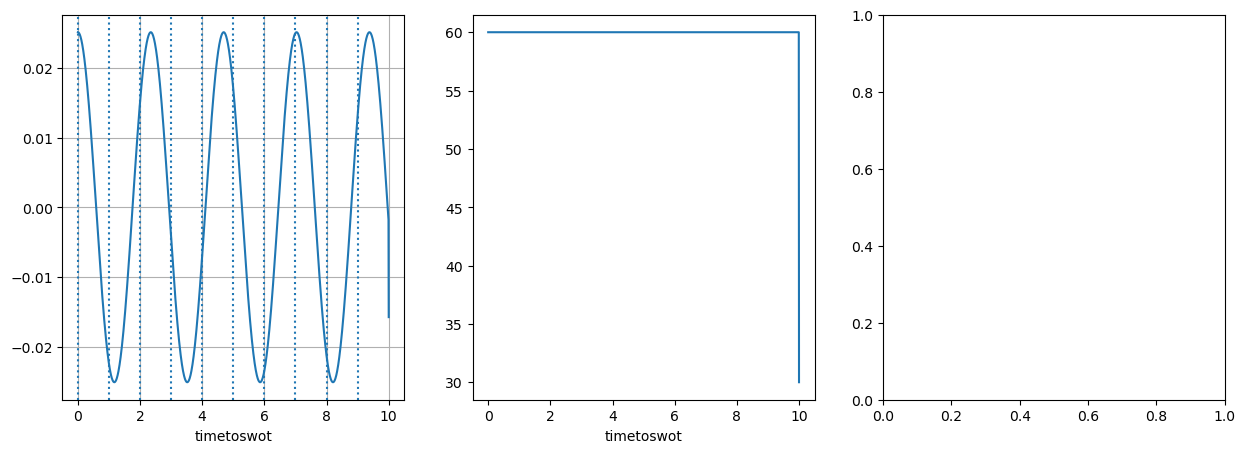

In [150]:
plot_for_one_traj(simple.sel(tcycle = slice(10,40)), bended.sel(tcycle = slice(10,40)), 0)
plot_for_all(simple.sel(tcycle = slice(10,40)), bended.sel(tcycle = slice(10,40)))

### T=4.1

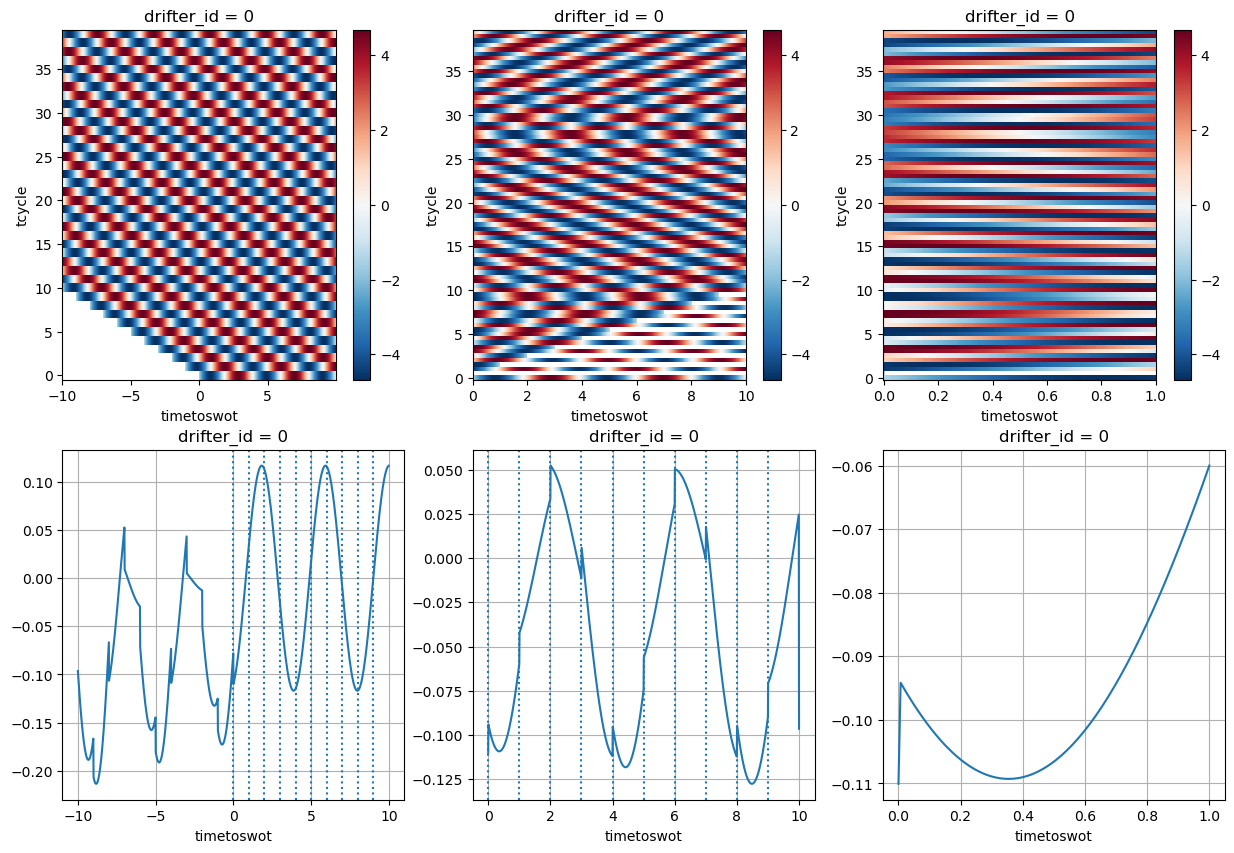

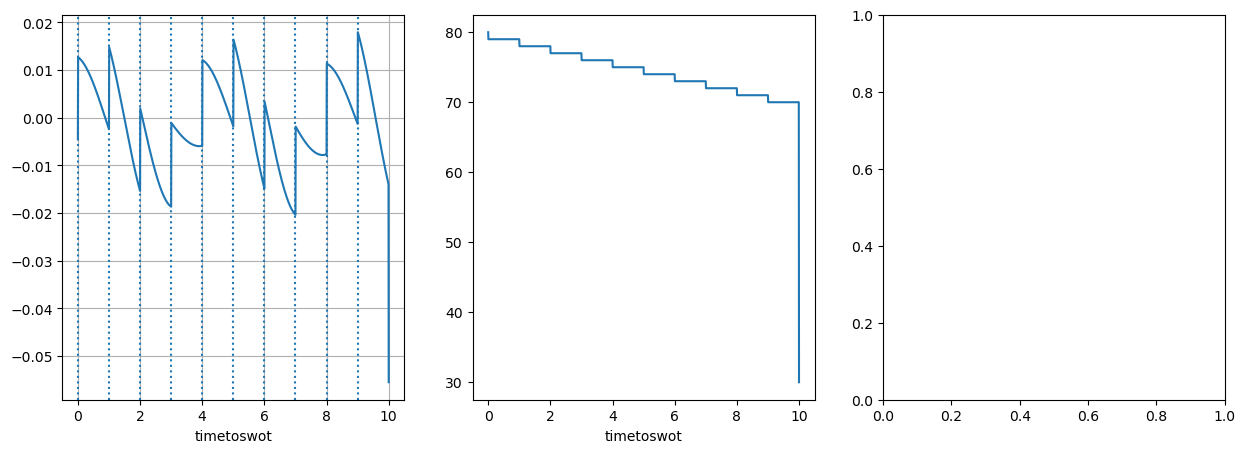

In [151]:
dsggd, bended, simple = compute_for_all(T=4.1)
plot_for_one_traj(simple, bended, 0)
plot_for_all(simple, bended)

### dCycle = 3

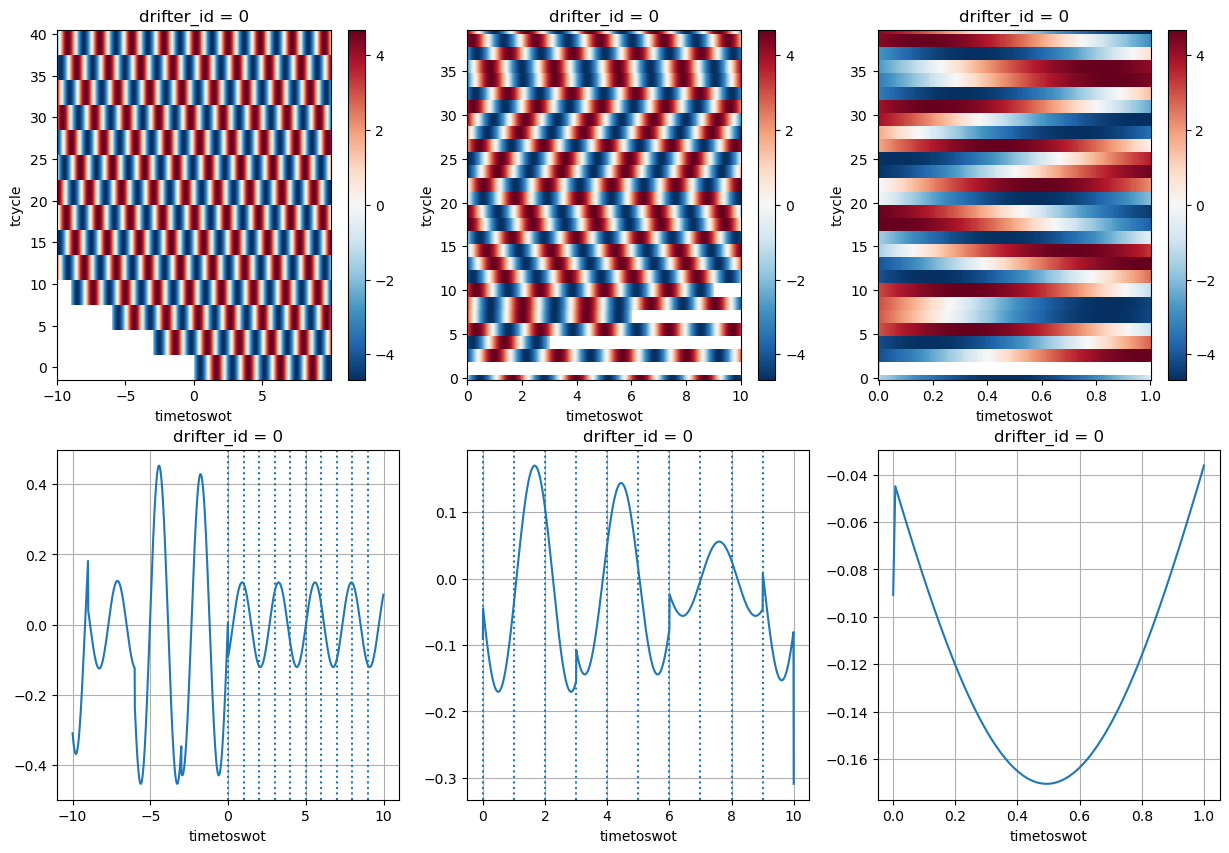

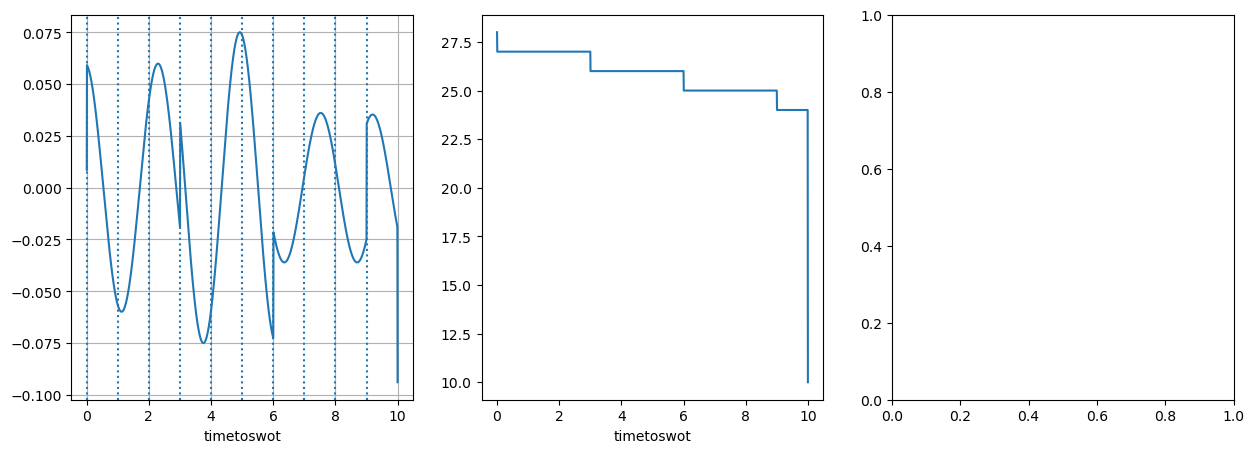

In [152]:
dsggd, bended, simple = compute_for_all(dtCycle=3)
plot_for_one_traj(simple, bended, 0)
plot_for_all(simple, bended)

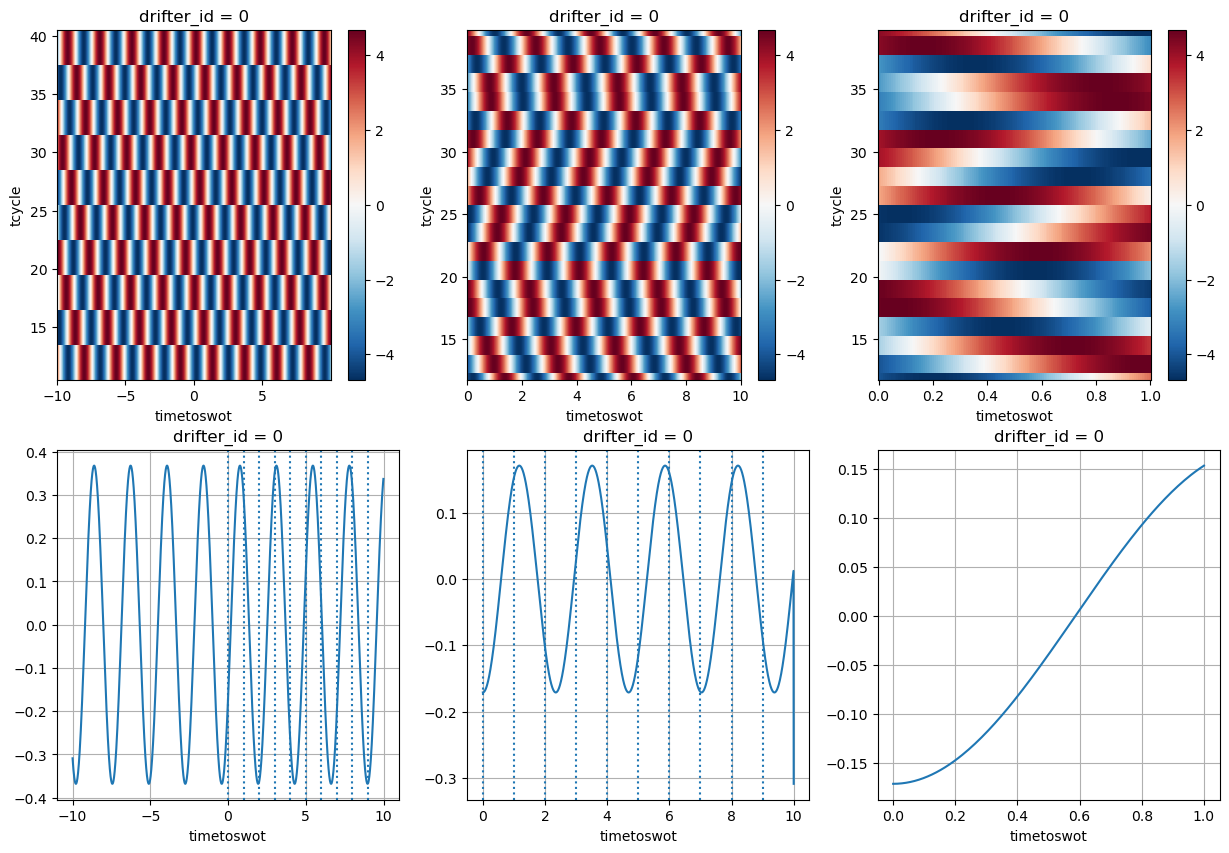

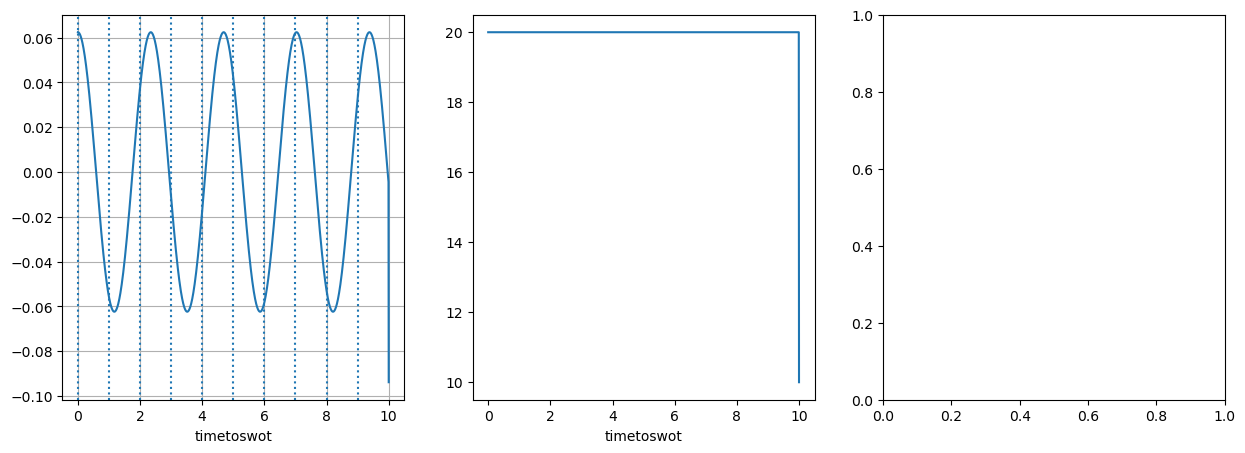

In [153]:
plot_for_one_traj(simple.sel(tcycle = slice(10,40)), bended.sel(tcycle = slice(10,40)), 0)
plot_for_all(simple.sel(tcycle = slice(10,40)), bended.sel(tcycle = slice(10,40)))

### dt = 0.5

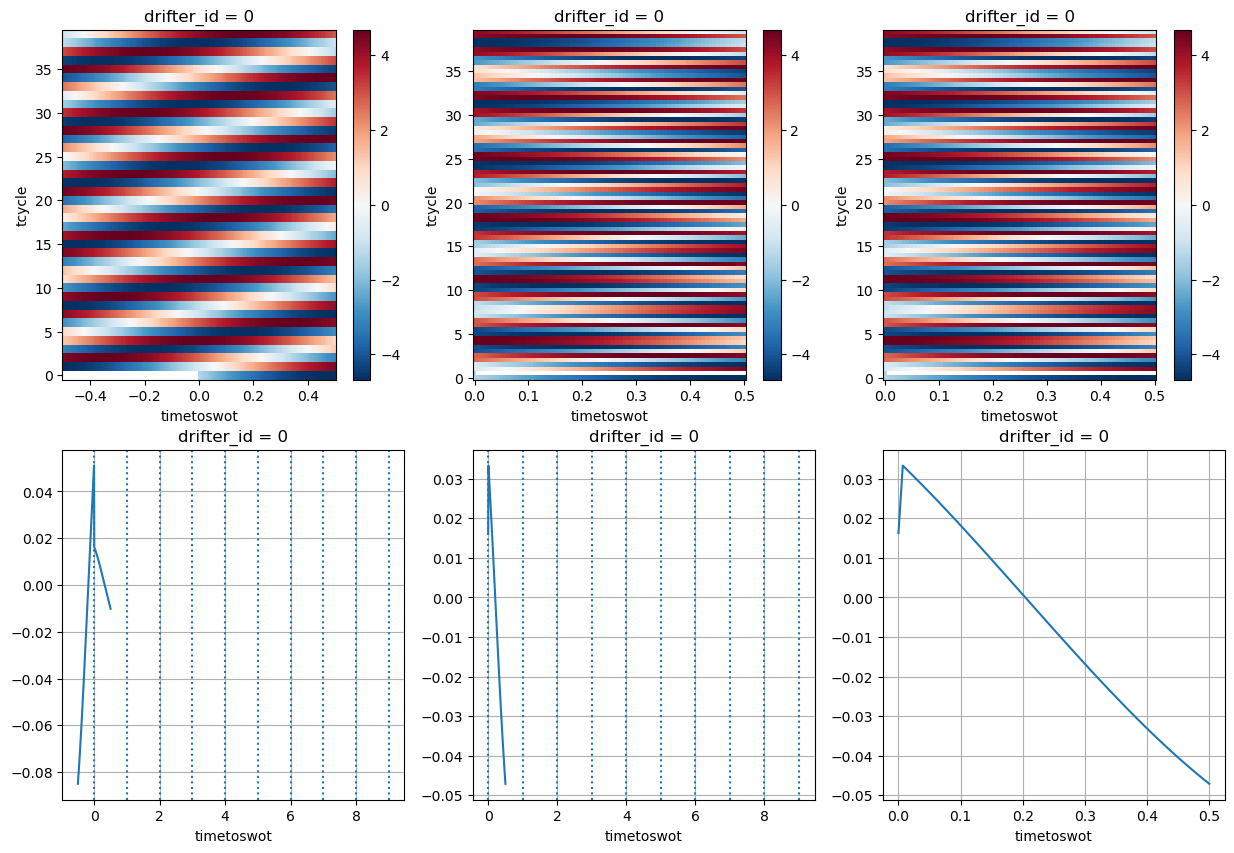

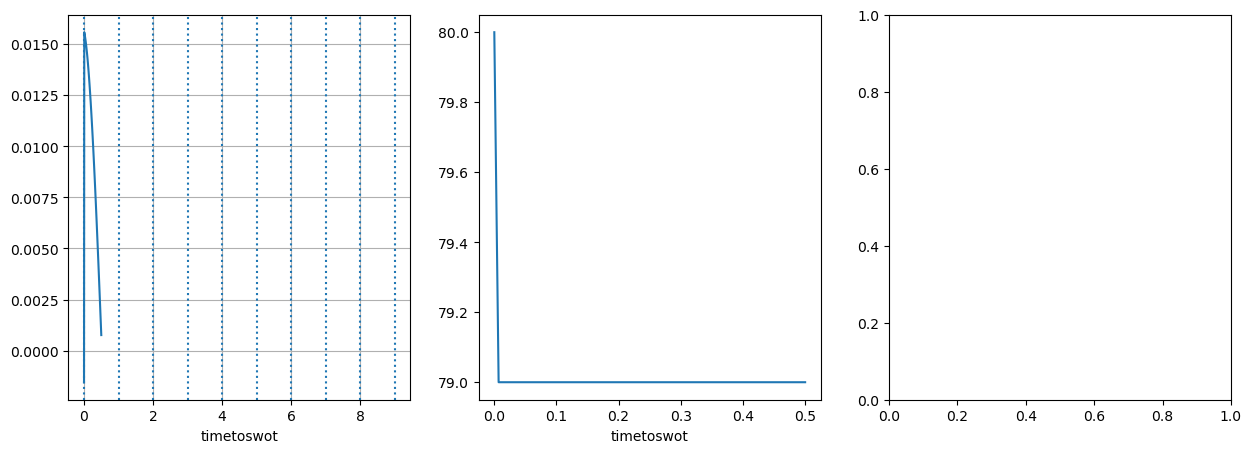

In [154]:
dsggd, bended, simple = compute_for_all(dt=0.5)
plot_for_one_traj(simple, bended, 0)
plot_for_all(simple, bended)